In [1]:
# Libraries
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
import pyarrow.dataset as ds

In [2]:
dataset = ds.dataset("dataset", format="parquet")
table = dataset.to_table()
df = table.to_pandas()
df = df[['timestamp', 'out.electricity.net.energy_consumption']]

# Aggregating
df = (
    df.groupby("timestamp")["out.electricity.net.energy_consumption"]
    .sum()
    .reset_index()
)


In [3]:
df.describe()

,timestamp,out.electricity.net.energy_consumption
count,35040,35040.000000
mean,2007-07-02 12:07:30,18.880628
min,2007-01-01 00:15:00,8.542000
25%,2007-04-02 06:11:15,14.398000
50%,2007-07-02 12:07:30,18.283000
75%,2007-10-01 18:03:45,22.632500
max,2008-01-01 00:00:00,39.921000
std,NaN,5.684677


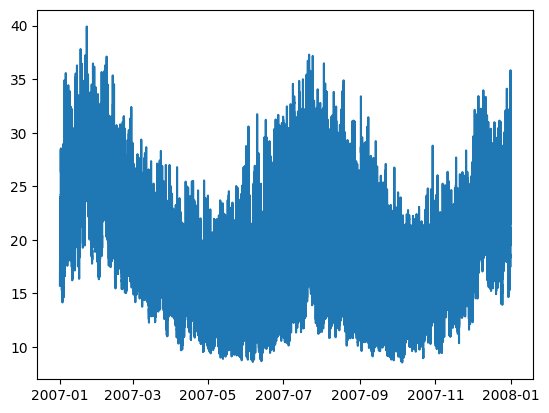

In [4]:
plt.plot(df['timestamp'], df['out.electricity.net.energy_consumption'])

In [41]:
## CVAR with no curtailment budget
## Ensuring the expected tail loss is below epsilon with confidence level alpha

# parameters
alpha = 0.95
epsilon = 0


# Decision Variables
C = cp.Variable(nonneg=True, name="C")
eta = cp.Variable(name="eta")
s = cp.Variable(T, nonneg=True, name="s")

constraints = [
    s >= C * lhat - c_res - eta,
    eta + (1.0 / ((1.0 - alpha) * T)) * cp.sum(s) <= epsilon,
    
]

obj = cp.Maximize(C)
problem = cp.Problem(obj, constraints)

problem.solve(solver="ECOS", verbose=True)

print("Optimal C:", C.value)

(CVXPY) Mar 10 02:43:23 AM: Your problem has 35042 variables, 35041 constraints, and 0 parameters.
(CVXPY) Mar 10 02:43:23 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Mar 10 02:43:23 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Mar 10 02:43:23 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Mar 10 02:43:23 AM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Mar 10 02:43:23 AM: Compiling problem (target solver=ECOS).
(CVXPY) Mar 10 02:43:23 AM: Reduction chain: FlipObjective -> Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> ECOS
(CVXPY) Mar 10 02:43:23 AM: Applying reduction FlipObjective
(CVXPY) Mar 10 02:43:23 AM: Applying reduction Dcp2Cone
(CVXPY) Mar 10 02:43:23 AM: Applying reduction CvxAttr2Constr
(CVXPY) Mar 10 02:43:23 AM: Applying reduction ConeMatrixStuffing
(CVXPY) Mar 10 02:43:23 AM: Apply

                                     CVXPY                                     
                                     v1.7.5                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------


(CVXPY) Mar 10 02:43:23 AM: Problem status: optimal
(CVXPY) Mar 10 02:43:23 AM: Optimal value: 1.196e+01
(CVXPY) Mar 10 02:43:23 AM: Compilation took 5.938e-02 seconds
(CVXPY) Mar 10 02:43:23 AM: Solver (including time spent in interface) took 2.791e-01 seconds


-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
Optimal C: 11.96190524962698


In [ ]:
## CVAR with curtailment budget


alpha = 0.95
epsilon = 0.0
dt = 0.25      # 15-minute intervals
B_mwh = 25.0   # total curtailed energy budget in MWh
mu = 0.2       # max 20% curtailment per timestamp

C = cp.Variable(nonneg=True, name="C")
eta = cp.Variable(name="eta")
s = cp.Variable(T, nonneg=True, name="s")
y = cp.Variable(T, nonneg=True, name="y")

zeta = C * lhat - y - c_res

constraints = [
    s >= zeta - eta,
    eta + (1.0 / ((1.0 - alpha) * T)) * cp.sum(s) <= epsilon,

    y <= C * lhat,          # cannot curtail more than requested load
    y <= mu * C * lhat,     # optional per-slot curtailment cap
    cp.sum(y) * dt <= B_mwh
]

obj = cp.Maximize(C)
problem = cp.Problem(obj, constraints)

problem.solve(solver=cp.CLARABEL, verbose=True)

print("Optimal C:", C.value)
print("Total curtailed energy (MWh):", y.value.sum() * dt)

(CVXPY) Mar 10 02:43:25 AM: Your problem has 70082 variables, 105122 constraints, and 0 parameters.
(CVXPY) Mar 10 02:43:25 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Mar 10 02:43:25 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Mar 10 02:43:25 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Mar 10 02:43:25 AM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Mar 10 02:43:25 AM: Compiling problem (target solver=CLARABEL).
(CVXPY) Mar 10 02:43:25 AM: Reduction chain: FlipObjective -> Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> CLARABEL
(CVXPY) Mar 10 02:43:25 AM: Applying reduction FlipObjective
(CVXPY) Mar 10 02:43:25 AM: Applying reduction Dcp2Cone
(CVXPY) Mar 10 02:43:25 AM: Applying reduction CvxAttr2Constr
(CVXPY) Mar 10 02:43:25 AM: Applying reduction ConeMatrixStuffing
(CVXPY) Mar 10 02:43:25 

                                     CVXPY                                     
                                     v1.7.5                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
-------------------------------------------------------------
           Clarabel.rs v0.11.1  -  Clever Acronym                

                   (c) Paul Goulart                          
                University of Oxford, 2022                   
-------------------------------------------------------------

problem:
  variables     = 70082
  constrain

(CVXPY) Mar 10 02:43:27 AM: Problem status: optimal
(CVXPY) Mar 10 02:43:27 AM: Optimal value: 1.202e+01
(CVXPY) Mar 10 02:43:27 AM: Compilation took 1.316e-01 seconds
(CVXPY) Mar 10 02:43:27 AM: Solver (including time spent in interface) took 1.050e+00 seconds


 24  -1.2019e+01  -1.2019e+01  6.75e-09  1.15e-13  3.66e-11  4.79e-13  1.57e-12  9.90e-01  
---------------------------------------------------------------------------------------------
Terminated with status = Solved
solve time = 1.0027543s
-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
Optimal C: 12.01898284596558
Total curtailed energy (MWh): 24.999999999818368


In [ ]:
#Let's just say I don't want t 